### Capturing Order of Words
- We capture moving window of words, to capture order
- bigram or n gram, width of window
- BOW is special case where n = 1

In [1]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer(ngram_range=(1,2))
v.fit(["""In a world where technology evolves at an unprecedented pace,However, the rapid integration of technology comes with its own set of challenges. Privacy concerns have emerged as a critical issue, with individuals increasingly wary of how their personal data is collected, stored, and used. Cybersecurity threats have also become more sophisticated, posing risks to both individuals and organizations. As we embrace the benefits of technology, it is imperative to address these challenges to ensure a safe and secure digital environment. Another pressing issue is the digital divide, which highlights the disparity in access to technology between different regions and communities. While urban areas often enjoy high-speed internet and advanced infrastructure, rural and underprivileged communities may lack basic access to these resources. Bridging this gap is essential to ensure that everyone can reap the benefits of technological advancements.

Education has been one of the most affected sectors, as technology has reshaped traditional learning methods. Online courses, virtual classrooms, and educational apps have made learning more flexible and accessible. Students can now access a wealth of knowledge and resources from anywhere in the world. Moreover, personalized learning tools driven by artificial intelligence can adapt to individual needs, enhancing the learning experience. However, this shift also raises concerns about screen time, digital distractions, and the potential loss of interpersonal skills that are cultivated in traditional classroom settings.

Healthcare is another area that has seen remarkable innovations. Telemedicine enables patients to consult doctors remotely, eliminating the need for physical visits in many cases. Wearable devices and health monitoring apps provide real-time insights into one’s health, encouraging proactive care. Furthermore, advances in medical technology, such as robotic surgeries and precision medicine, have improved patient outcomes significantly. Despite these benefits, ethical dilemmas surrounding medical data usage and affordability persist, requiring careful consideration.

As we look to the future, it is evident that technology will continue to play a pivotal role in shaping our lives. Emerging trends such as the Internet of Things, blockchain, and quantum computing hold immense potential to drive further innovation. However, as we harness these advancements, we must remain mindful of their societal and ethical implications. By fostering a culture of responsibility, inclusivity, and collaboration, we can create a technological landscape that benefits everyone, ensuring a brighter future for generations to come the way we communicate, work, and interact has been transformed. Digital platforms have become an integral part of our daily lives, reshaping how we connect with each other across the globe. Social media, for instance, allows individuals to share moments, ideas, and experiences instantaneously, bridging geographical distances. Similarly, email and instant messaging have replaced traditional forms of communication, offering speed and convenience. In this fast-paced digital age, businesses have also undergone significant transformations. Companies now leverage artificial intelligence, big data, and cloud computing to optimize operations and enhance decision-making. These innovations have not only improved efficiency but also created new opportunities for growth. For example, e-commerce has revolutionized the retail industry, enabling customers to shop from the comfort of their homes. Online marketplaces offer an extensive range of products, often at competitive prices, making shopping more accessible and affordable."""])
print(v.vocabulary_)
print(len(v.vocabulary_))

{'in': 368, 'world': 817, 'where': 803, 'technology': 691, 'evolves': 278, 'at': 85, 'an': 35, 'unprecedented': 775, 'pace': 549, 'however': 353, 'the': 707, 'rapid': 598, 'integration': 406, 'of': 503, 'comes': 146, 'with': 811, 'its': 432, 'own': 547, 'set': 647, 'challenges': 131, 'privacy': 584, 'concerns': 166, 'have': 329, 'emerged': 245, 'as': 79, 'critical': 185, 'issue': 427, 'individuals': 383, 'increasingly': 379, 'wary': 787, 'how': 350, 'their': 723, 'personal': 561, 'data': 197, 'is': 420, 'collected': 142, 'stored': 678, 'and': 39, 'used': 781, 'cybersecurity': 193, 'threats': 739, 'also': 30, 'become': 90, 'more': 482, 'sophisticated': 673, 'posing': 573, 'risks': 629, 'to': 744, 'both': 106, 'organizations': 538, 'we': 791, 'embrace': 243, 'benefits': 96, 'it': 430, 'imperative': 361, 'address': 12, 'these': 727, 'ensure': 261, 'safe': 637, 'secure': 643, 'digital': 209, 'environment': 266, 'another': 63, 'pressing': 580, 'divide': 223, 'which': 805, 'highlights': 344,

In [2]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [2]:
import spacy

nlp = spacy.load('en_core_web_sm')

def preprocess(text):
    doc = nlp(text)

    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)

    return " ".join(filtered_tokens)

In [9]:
corpus_processed = [preprocess(text) for text in corpus]
corpus_processed

['thor eat pizza', 'Loki tall', 'Loki eat pizza']

In [10]:
v = CountVectorizer(ngram_range=(1,2))

v.fit_transform(corpus_processed)

<3x9 sparse matrix of type '<class 'numpy.int64'>'
	with 13 stored elements in Compressed Sparse Row format>

In [12]:
print(v.vocabulary_)

{'thor': 7, 'eat': 0, 'pizza': 5, 'thor eat': 8, 'eat pizza': 1, 'loki': 2, 'tall': 6, 'loki tall': 4, 'loki eat': 3}


In [19]:
v.transform(['Hult ate pizza']).toarray()

array([[0, 0, 0, 0, 0, 1, 0, 0, 0]])

In [3]:
import pandas as pd

df = pd.read_json('Data Files/news_dataset.json')
print(df.info(),'\n',df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 12695 entries, 0 to 12694
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      12695 non-null  object
 1   category  12695 non-null  object
dtypes: object(2)
memory usage: 297.5+ KB
None 
                                         text  category
count                                  12695     12695
unique                                 12689         4
top     9 Terrifying American Murder Houses   BUSINESS
freq                                       2      4254
                                                text  category
0  Watching Schrödinger's Cat Die University of C...   SCIENCE
1     WATCH: Freaky Vortex Opens Up In Flooded Lake    SCIENCE
2  Entrepreneurs Today Don't Need a Big Budget to...  BUSINESS
3  These Roads Could Recharge Your Electric Car A...  BUSINESS
4  Civilian 'Guard' Fires Gun While 'Protecting' ...     CRIME


In [22]:
df['category'].value_counts()

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

In [49]:
# Using under sampling for Data Imbalance
min_samples = 1381

bus = df[df['category'] == 'BUSINESS'].sample(min_samples)
sci = df[df['category'] == 'SCIENCE'].sample(min_samples)
cri = df[df['category'] == 'CRIME'].sample(min_samples)
sprt = df[df['category'] == 'SPORTS'].sample(min_samples)


In [52]:
df_und_sampled = pd.concat([bus,sci,cri,sprt],axis=0)
df_und_sampled['category'].value_counts()

category
BUSINESS    1381
SCIENCE     1381
CRIME       1381
SPORTS      1381
Name: count, dtype: int64

In [58]:
target = {
    'BUSINESS':0,
    'SCIENCE' : 1,
    'CRIME' : 2,
    'SPORTS' : 3
}

df_und_sampled['target'] = df_und_sampled['category'].map(target)
df_und_sampled.sample(10)

,text,category,target
9194,Face-Aging Software Presents a Terrible (and F...,SCIENCE,1
11689,Tampa Bay Rays To Play In Cuba During Presiden...,SPORTS,3
6315,SCOTUS Ruling Could Spell Big Trouble For U.S.,BUSINESS,0
1757,Video Captures A Violent Brawl Between KKK And...,CRIME,2
9448,Anti-Tesla States Jabbed With Luddite 'Award',BUSINESS,0
7698,James Corden And Stephen Curry Are A Fierce 'C...,SPORTS,3
3845,Even 'Sesame Street' Seems To Have Poked Fun A...,SPORTS,3
3078,Can Dogs Smell Their ‘Reflections’? If you wan...,SCIENCE,1
5864,Mysterious Light Seen Near Huge Black Hole,SCIENCE,1
253,Man Stabs Fellow Churchgoer During Service For...,CRIME,2


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_und_sampled['text'],df_und_sampled['target'],test_size=0.2,stratify=df_und_sampled['target'])

In [63]:
y_test

4175     3
3370     3
9024     1
6887     2
5053     3
        ..
1429     3
11451    1
953      2
6281     2
7179     1
Name: target, Length: 1105, dtype: int64

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [68]:



ppl1 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,2))),
    ('nb',MultinomialNB())
])

ppl2 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,2))),
    ('knn',KNeighborsClassifier())
])

ppl3 = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1,2))),
    ('rf',RandomForestClassifier())
])

ppl1.fit(X_train,y_train)
ppl2.fit(X_train,y_train)
ppl3.fit(X_train,y_train)

print('Classification Report of Naive Bayes\n')
print(classification_report(y_test,ppl1.predict(X_test)))

print('Classification Report of KNN\n')
print(classification_report(y_test,ppl2.predict(X_test)))

print('Classification Report of Random Forest\n')
print(classification_report(y_test,ppl3.predict(X_test)))

Classification Report of Naive Bayes

              precision    recall  f1-score   support

           0       0.74      0.88      0.80       277
           1       0.89      0.82      0.85       276
           2       0.90      0.89      0.90       276
           3       0.92      0.82      0.87       276

    accuracy                           0.85      1105
   macro avg       0.86      0.85      0.85      1105
weighted avg       0.86      0.85      0.85      1105

Classification Report of KNN

              precision    recall  f1-score   support

           0       0.26      0.86      0.40       277
           1       0.50      0.04      0.07       276
           2       1.00      0.00      0.01       276
           3       0.23      0.14      0.17       276

    accuracy                           0.26      1105
   macro avg       0.50      0.26      0.16      1105
weighted avg       0.50      0.26      0.16      1105

Classification Report of Random Forest

              precisio

In [69]:
df_und_sampled['preprocessed'] = df_und_sampled['text'].apply(preprocess)
df_und_sampled

,text,category,target,preprocessed
9069,Over 165 Countries Set To Sign Paris Agreement...,BUSINESS,0,165 country Set sign Paris Agreement big step ...
5699,Cyber Fraudsters Reap Billions Through Email W...,BUSINESS,0,Cyber Fraudsters Reap Billions Email Wire Tran...
6849,"In Los Angeles, Bitter Tensions Over Where To ...",BUSINESS,0,Los Angeles Bitter Tensions House Homeless Ril...
3332,Why Tax Collection Scams Are Getting Harder To...,BUSINESS,0,Tax Collection Scams get hard stop leave frien...
6062,Why You Should Be Using LinkedIn More Like Fac...,BUSINESS,0,linkedin like Facebook need know look smart hi...
...,...,...,...,...
5271,Watch Maria Sharapova Feel All The Feels After...,SPORTS,3,watch Maria Sharapova feel Feels Upset Win U.S...
404,Atlanta Falcons Strike Gold Hiring Steve Sarki...,SPORTS,3,Atlanta Falcons Strike Gold hire Steve Sarkisi...
10587,Anthony Davis 'Guarantees' Kentucky's National...,SPORTS,3,Anthony Davis Guarantees Kentucky National Title
5134,MLB Player Breaks Bat... On A Whiff,SPORTS,3,MLB Player Breaks Bat Whiff


In [70]:
X_train, X_test, y_train, y_test = train_test_split(df_und_sampled['preprocessed'],df_und_sampled['target'],test_size=0.2,stratify=df_und_sampled['target'])

ppl1.fit(X_train,y_train)
ppl2.fit(X_train,y_train)
ppl3.fit(X_train,y_train)

print('Classification Report of Naive Bayes\n')
print(classification_report(y_test,ppl1.predict(X_test)))

print('Classification Report of KNN\n')
print(classification_report(y_test,ppl2.predict(X_test)))

print('Classification Report of Random Forest\n')
print(classification_report(y_test,ppl3.predict(X_test)))

Classification Report of Naive Bayes

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       277
           1       0.90      0.85      0.87       276
           2       0.88      0.94      0.91       276
           3       0.94      0.84      0.89       276

    accuracy                           0.88      1105
   macro avg       0.88      0.88      0.88      1105
weighted avg       0.88      0.88      0.88      1105

Classification Report of KNN

              precision    recall  f1-score   support

           0       0.26      0.99      0.41       277
           1       0.50      0.01      0.01       276
           2       1.00      0.00      0.01       276
           3       0.71      0.10      0.17       276

    accuracy                           0.27      1105
   macro avg       0.62      0.27      0.15      1105
weighted avg       0.62      0.27      0.15      1105

Classification Report of Random Forest

              precisio

### Exercise


In [5]:
import pandas as pd

df = pd.read_csv('Data Files/Fake_Real_Data.csv')
print(df.info(),'\n',df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9900 entries, 0 to 9899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    9900 non-null   object
 1   label   9900 non-null   object
dtypes: object(2)
memory usage: 154.8+ KB
None 
                                                      Text label
count                                                9900  9900
unique                                               9865     2
top     Highlights: The Trump presidency on April 13 a...  Fake
freq                                                    8  5000
                                                Text label
0   Top Trump Surrogate BRUTALLY Stabs Him In The...  Fake
1  U.S. conservative leader optimistic of common ...  Real
2  Trump proposes U.S. tax overhaul, stirs concer...  Real
3   Court Forces Ohio To Allow Millions Of Illega...  Fake
4  Democrats say Trump agrees to work on immigrat...  Real


In [6]:
df['label'].value_counts()

label
Fake    5000
Real    4900
Name: count, dtype: int64

In [7]:
df['fake'] = df['label'].apply(lambda x: 1 if x == 'Fake' else 0)
df.head()

,Text,label,fake
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,1
1,U.S. conservative leader optimistic of common ...,Real,0
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,0
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,1
4,Democrats say Trump agrees to work on immigrat...,Real,0


In [8]:
# Modeling without preprocessing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['Text'],df['fake'],test_size=0.2,stratify=df['fake'])

In [6]:
print(X_train.shape,X_test.shape)

(7920,) (1980,)


### Attempt 1
- Model KNN 
- Metric Euclidean
- neighbours 10

In [11]:
from sklearn.pipeline import Pipeline

p1 = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,3))),
    ('knn',KNeighborsClassifier(n_neighbors=10, metric='euclidean'))
])

p1.fit(X_train,y_train)
print(classification_report(y_test,p1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.63      0.99      0.77       980
           1       0.98      0.42      0.59      1000

    accuracy                           0.70      1980
   macro avg       0.81      0.71      0.68      1980
weighted avg       0.81      0.70      0.68      1980



### Attempt 2
- Model with metric as cosine distance

In [14]:
p2 = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,3))),
    ('knn',KNeighborsClassifier(n_neighbors=10, metric='cosine'))
])

p2.fit(X_train,y_train)
print(classification_report(y_test,p2.predict(X_test)))

              precision    recall  f1-score   support

           0       0.64      1.00      0.78       980
           1       1.00      0.44      0.61      1000

    accuracy                           0.72      1980
   macro avg       0.82      0.72      0.69      1980
weighted avg       0.82      0.72      0.69      1980



### Attempt 3
- Model as RF

In [17]:
p3 = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(3,3))),
    ('rf',RandomForestClassifier(n_estimators=15))
])

p3.fit(X_train,y_train)
print(classification_report(y_test,p3.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.97      0.98      1000

    accuracy                           0.98      1980
   macro avg       0.98      0.98      0.98      1980
weighted avg       0.98      0.98      0.98      1980



### Attempt 4
- Model as Multinomial NB
- Alpha value 0.75

In [18]:
p4 = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,2))),
    ('rf',MultinomialNB(alpha=0.75))
])

p4.fit(X_train,y_train)
print(classification_report(y_test,p4.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



### Using Text preprocessing
- 

In [11]:
df['preprocessed'] = df['Text'].apply(preprocess)
df.head()

,Text,label,fake,preprocessed
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,1,Trump surrogate BRUTALLY Stabs Pathetic VIDE...
1,U.S. conservative leader optimistic of common ...,Real,0,U.S. conservative leader optimistic common gro...
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,0,trump propose U.S. tax overhaul stir concern d...
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,1,Court Forces Ohio allow Millions illegally p...
4,Democrats say Trump agrees to work on immigrat...,Real,0,Democrats Trump agree work immigration bill wa...


In [12]:
X_train, X_test, y_train, y_test = train_test_split(df['preprocessed'],df['fake'],test_size=0.2,random_state=2024,stratify=df['fake'])

### Attempt 1
- Model RF
- Only Trigrams

In [13]:
p_processed_1 = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(3,3))),
    ('rf',RandomForestClassifier(n_estimators=15))
])

p_processed_1.fit(X_train,y_train)
print(classification_report(y_test,p_processed_1.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93       980
           1       0.91      0.97      0.94      1000

    accuracy                           0.94      1980
   macro avg       0.94      0.93      0.94      1980
weighted avg       0.94      0.94      0.94      1980



### Attempt 2
- ngrams = (1,3)

In [14]:
p_processed_2 = Pipeline([
    ('vectorizer',CountVectorizer(ngram_range=(1,3))),
    ('rf',RandomForestClassifier(n_estimators=15))
])

p_processed_2.fit(X_train,y_train)
print(classification_report(y_test,p_processed_2.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1000

    accuracy                           0.99      1980
   macro avg       0.99      0.99      0.99      1980
weighted avg       0.99      0.99      0.99      1980



In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,p_processed_2.predict(X_test))

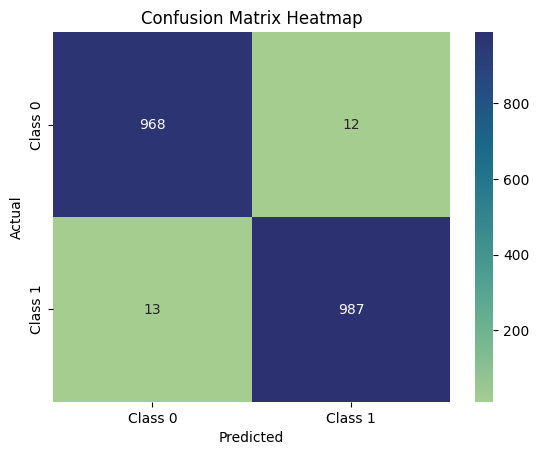

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="crest", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()
